<a href="https://colab.research.google.com/github/ajmalbiju56/ML/blob/main/insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install category_encoders

In [ ]:
#libaries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import KFold



In [ ]:
pd.options.mode.copy_on_write = True

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/expenses.csv")
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


# Data PreProcessing

* eda(explotaory data analysis)
* feature engineering
* model Building
* performance validation


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
df.tail(10)

,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


In [ ]:
#metadates of the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
#metadates of the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# data preprocessing
* handling null values
* handling duplicates
* checking for data type

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
#methods for handling null value
#*inteputation methods
#*drop null values


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

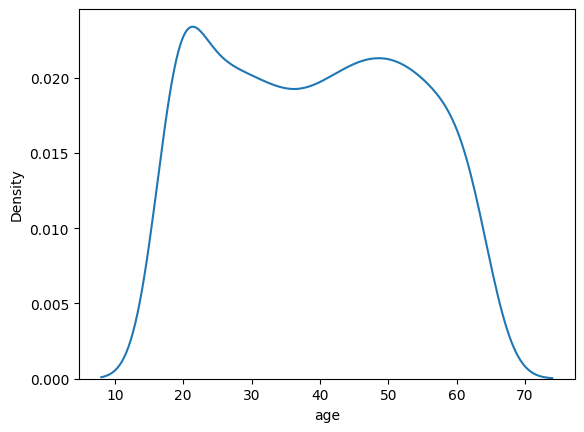

In [ ]:
sns.kdeplot(df['age'])
plt.show()

#univariate analysis

In [ ]:
#univariate
df['sex'].nunique()

2

In [ ]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [ ]:
df['sex'].value_counts()

,count
sex,
male,675
female,662


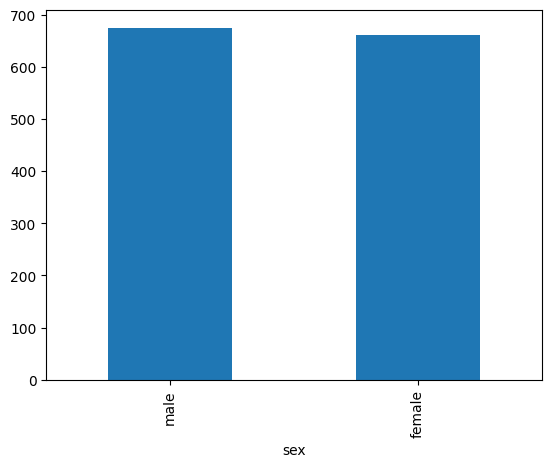

In [ ]:
df['sex'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
num= df.select_dtypes(include=np.number)
num.columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [ ]:
cat = df.select_dtypes(include=object)
cat.columns

Index(['sex', 'smoker', 'region'], dtype='object')

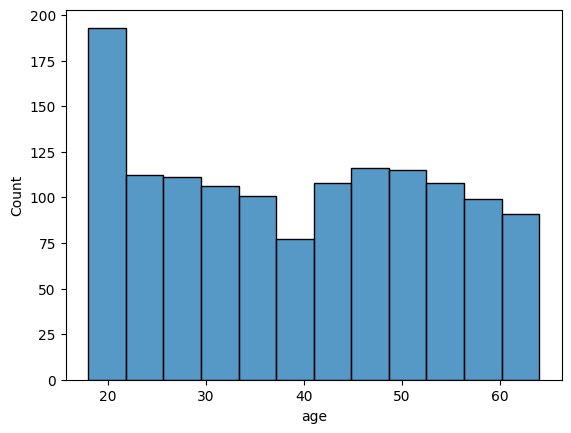

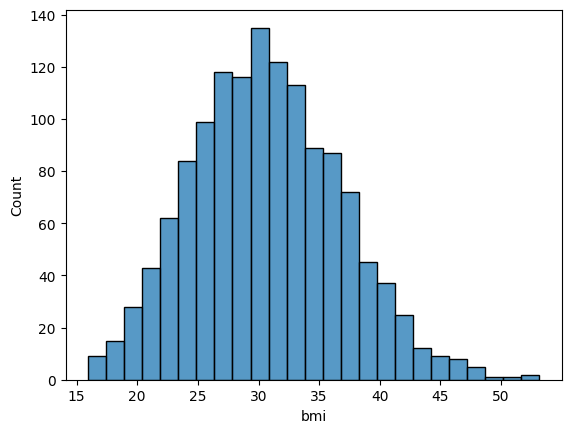

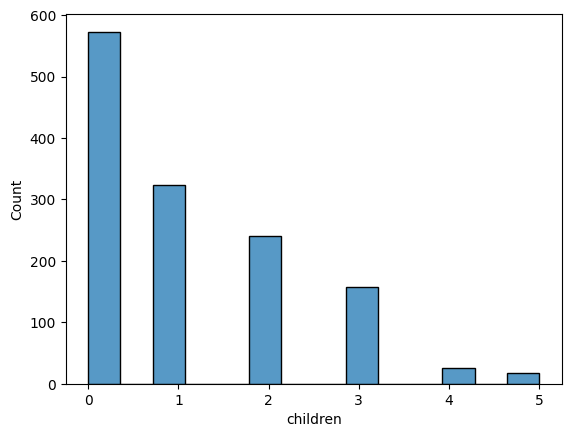

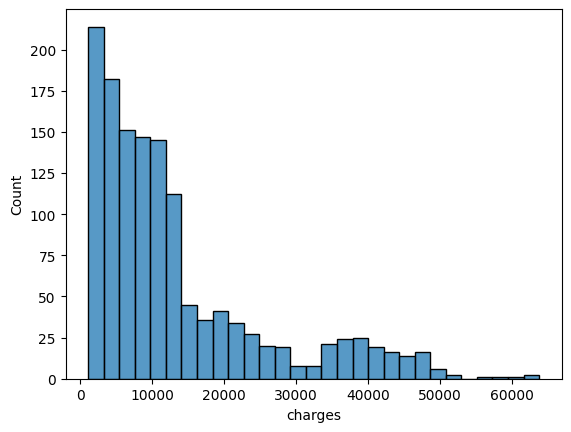

In [ ]:
# for numerical features
for i in num.columns:
  sns.histplot(df[i])
  plt.show()

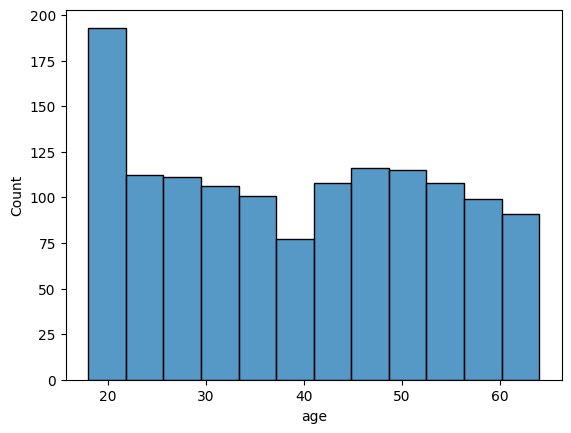

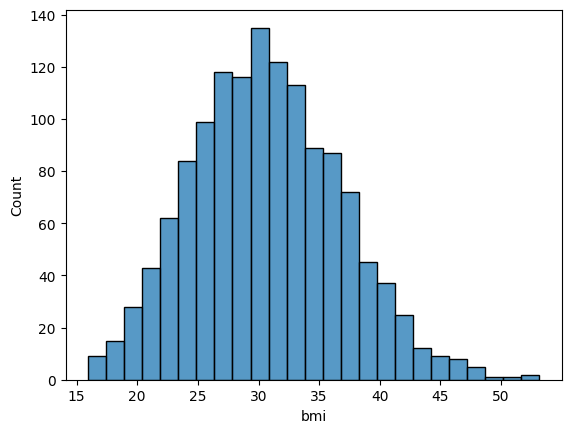

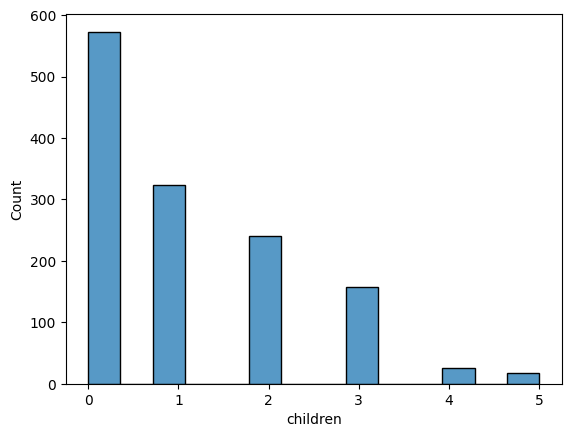

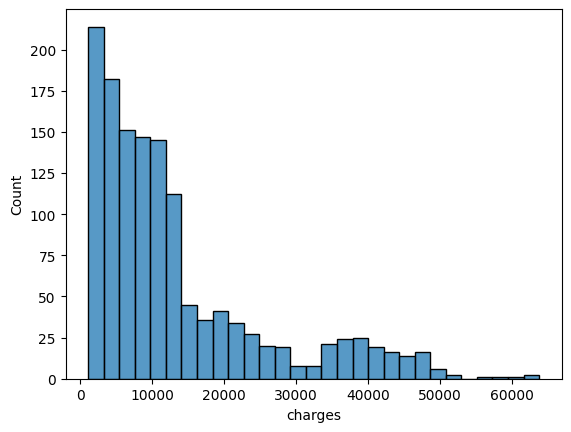

In [ ]:
for i in num.columns:
  sns.histplot(df[i])
  plt.show()

#bivariate analysis


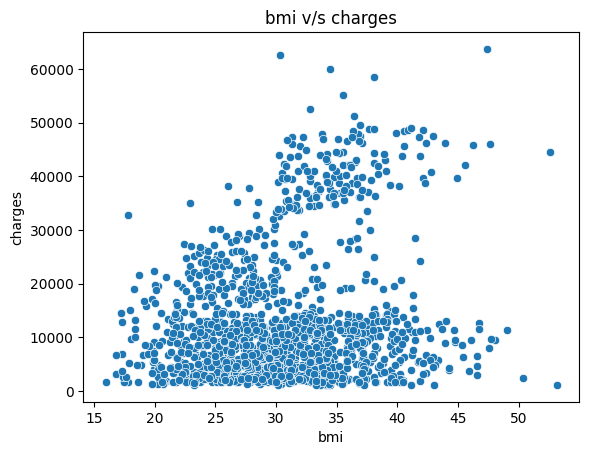

In [ ]:
#bivariate analysis for bmi and charges
sns.scatterplot(data=df,x='bmi',y='charges')
plt.title("bmi v/s charges")
plt.show()

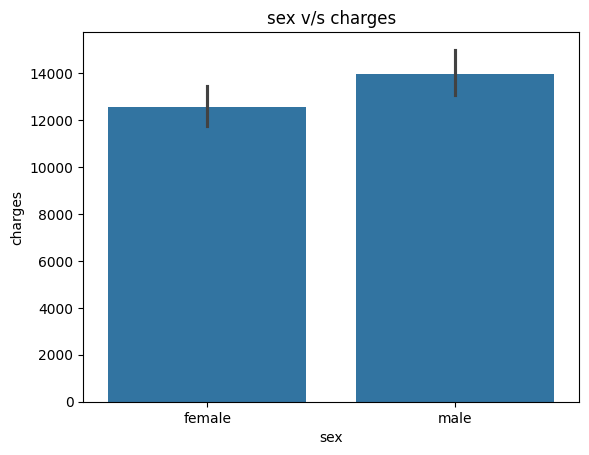

In [ ]:
#bivariate analysis of sex and charges
sns.barplot(data=df,x='sex',y='charges')
plt.title("sex v/s charges")
plt.show()

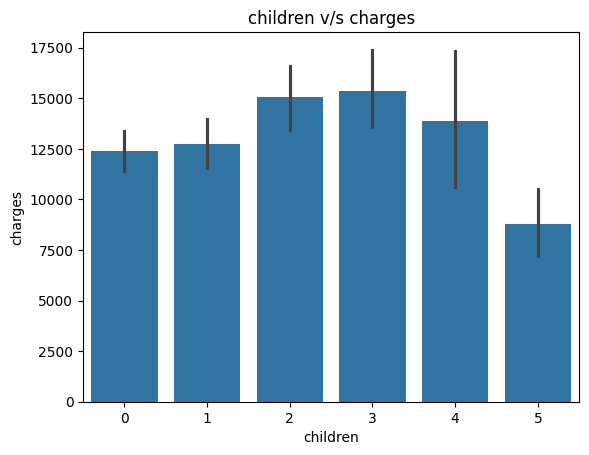

In [ ]:
#bivariate analysis of children and charges
sns.barplot(data=df,x='children',y='charges')
plt.title('children v/s charges')
plt.show()

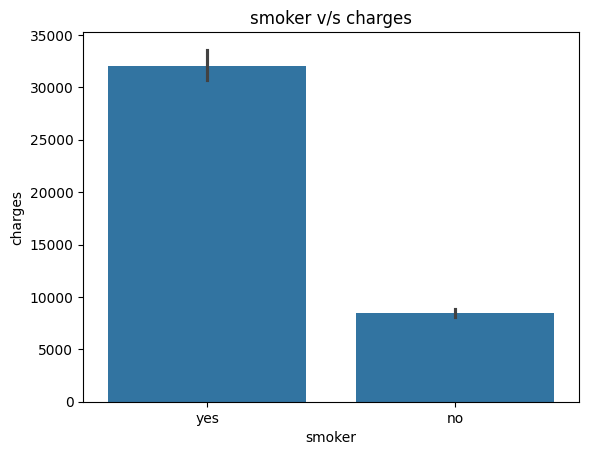

In [ ]:
#bivariate analysis of smoker and charges
sns.barplot(data=df,x='smoker',y='charges')
plt.title('smoker v/s charges')
plt.show()

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


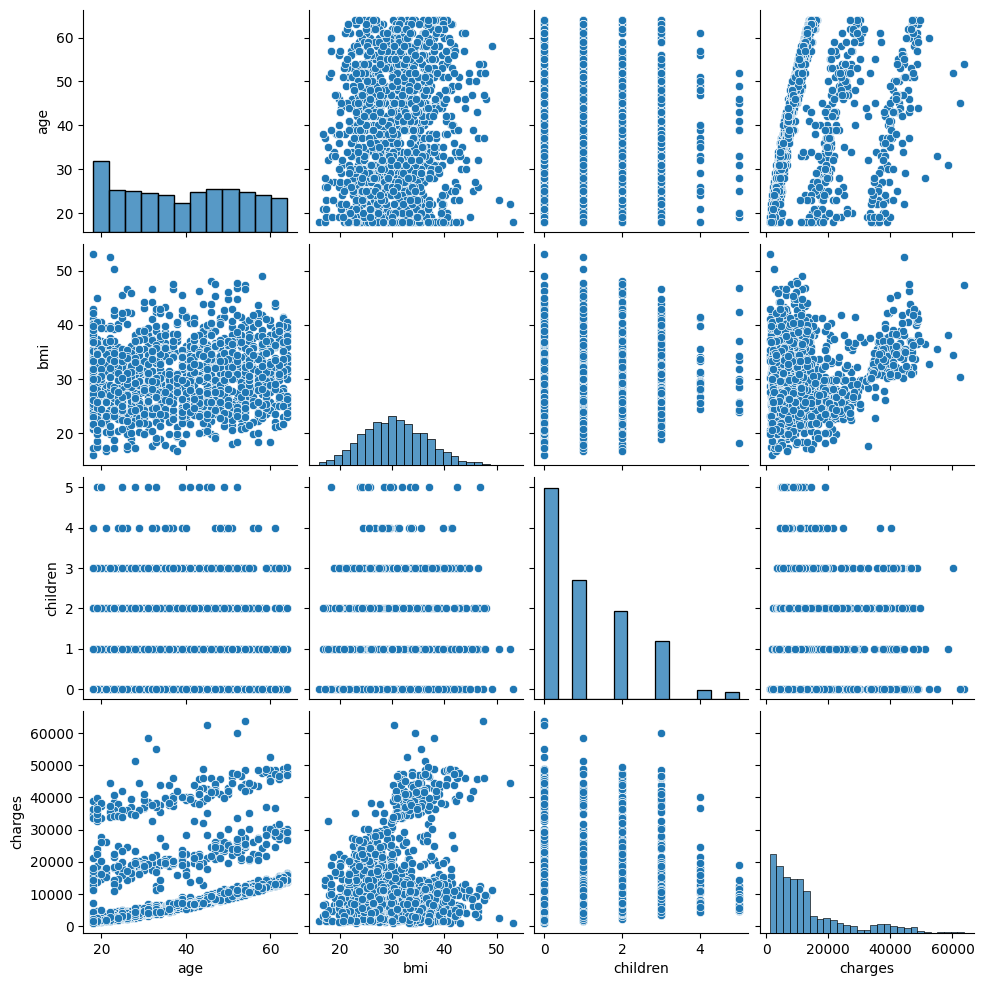

In [ ]:
sns.pairplot(df)
plt.show()

#multivariate analysis

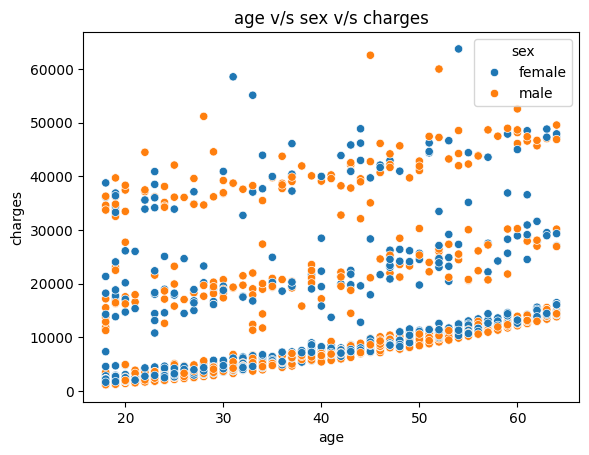

In [ ]:
#multivariate analysis of age,sex,charges
sns.scatterplot(data=df,x='age',y='charges',hue='sex')
plt.title("age v/s sex v/s charges")
plt.show()

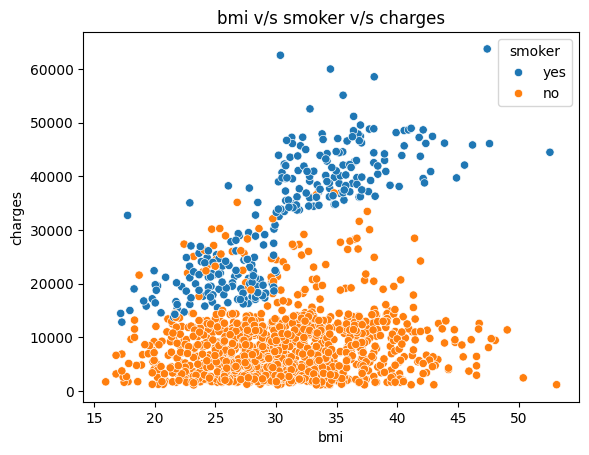

In [ ]:
#multivariate analysis of bmi,smoker,charges
sns.scatterplot(data=df,x='bmi',y='charges',hue='smoker')
plt.title("bmi v/s smoker v/s charges")
plt.show()

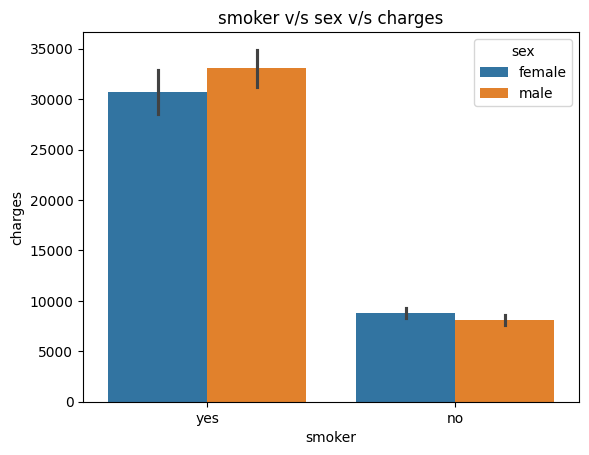

In [ ]:
#multivariate analysis of smoker,sex,charges
sns.barplot(data=df,x='smoker',y='charges',hue='sex')
plt.title("smoker v/s sex v/s charges")
plt.show()

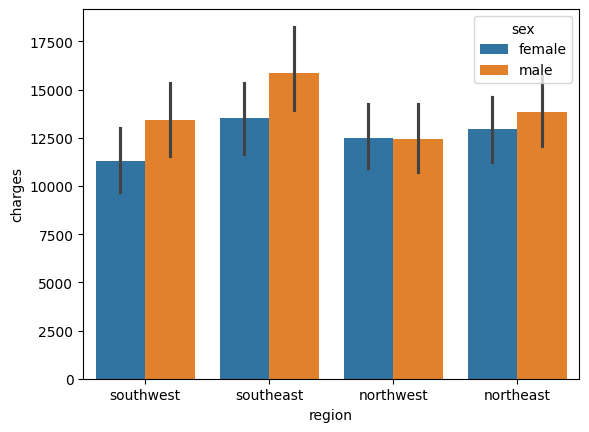

In [ ]:
#multivariate analysis of region,sex,charges
sns.barplot(data=df,x='region',y='charges',hue='sex')
plt.show()

In [ ]:
num=df.select_dtypes(include=np.number)
num.columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

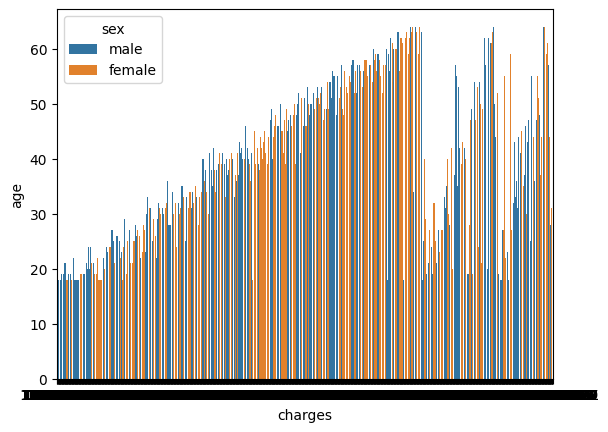

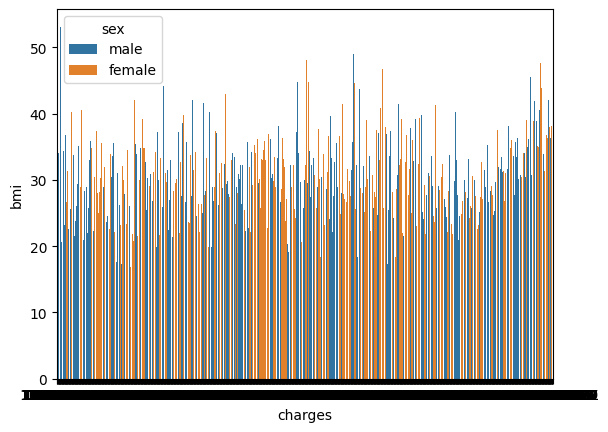

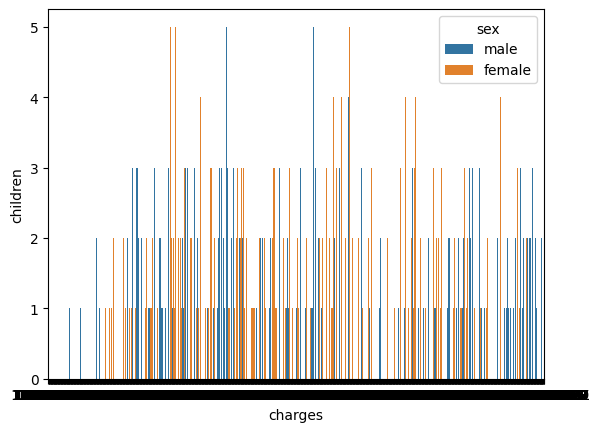

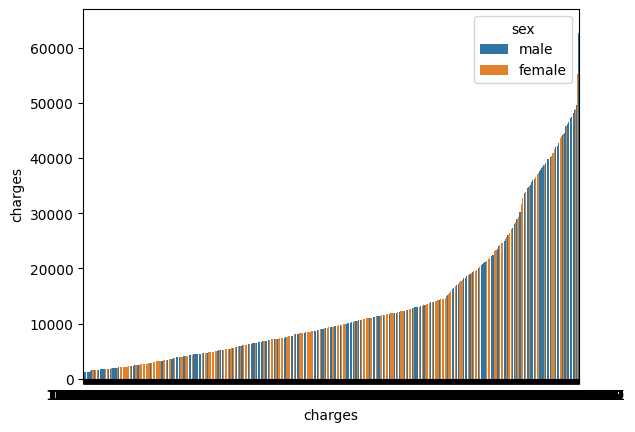

In [ ]:
num=df.select_dtypes(include=['number']).columns.tolist()
for i in num:
  sns.barplot(x=df['charges'],y=df[i],hue=df['sex'])
  plt.show()

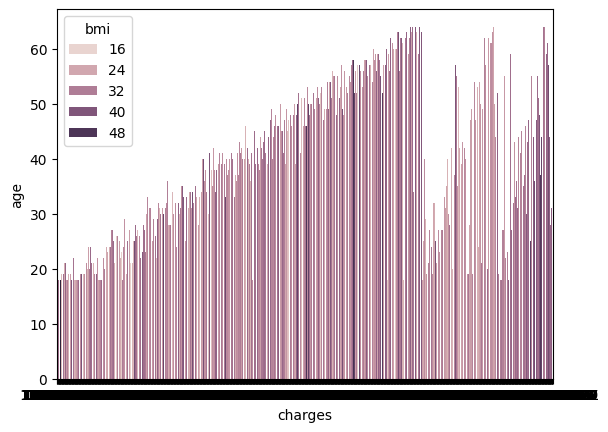

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


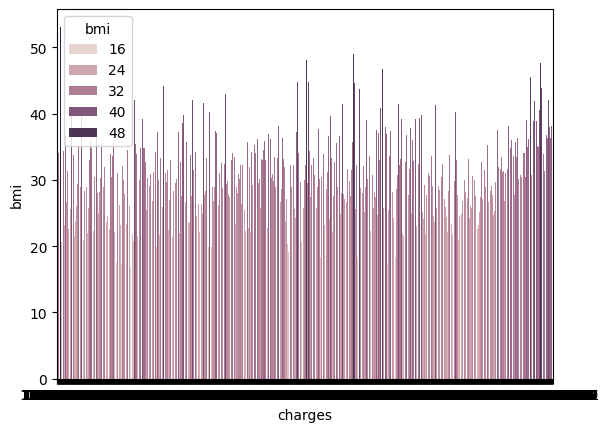

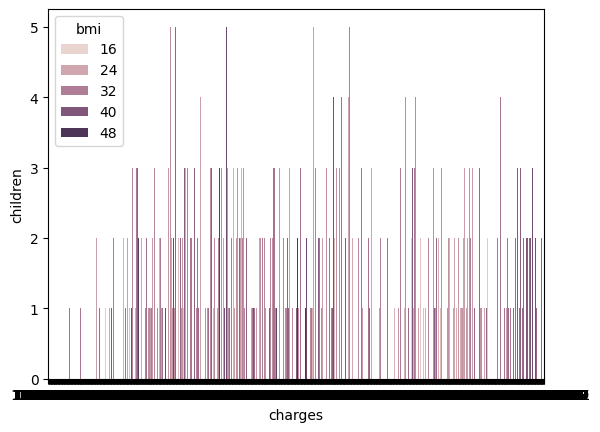

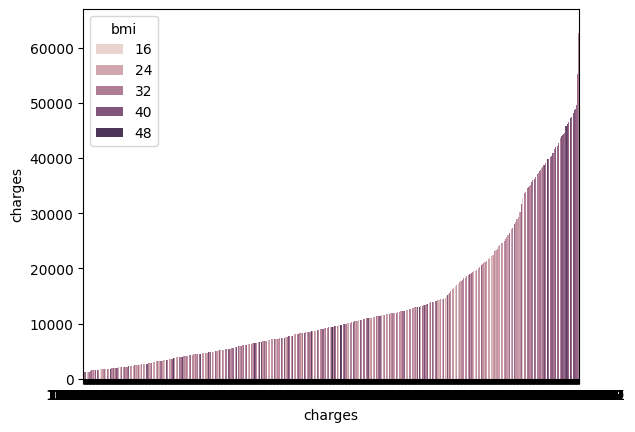

In [ ]:
num=df.select_dtypes(include=['number']).columns.tolist()
for i in num:
  sns.barplot(x=df['charges'],y=df[i],hue=df['bmi'])
  plt.show()

#Feature Engineering

#Data Encoding
* label encoding
* one hot encoding
*target encoding

#label encoding

In [ ]:
Ib_sex = LabelEncoder()
df['sex'] = Ib_sex.fit_transform(df['sex'])

In [ ]:
Ib_smoker = LabelEncoder()
df['smoker'] = Ib_sex.fit_transform(df['sex'])

# target encoding

In [ ]:
tb_region = TargetEncoder(cols=['region'])
df['region'] = tb_region.fit_transform(df['region'],df['charges'])

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,0,12346.937377,16884.92400
1,18,1,33.770,1,1,14735.411438,1725.55230
2,28,1,33.000,3,1,14735.411438,4449.46200
3,33,1,22.705,0,1,12450.840844,21984.47061
4,32,1,28.880,0,1,12450.840844,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,1,12450.840844,10600.54830
1334,18,0,31.920,0,0,13406.384516,2205.98080
1335,18,0,36.850,0,0,14735.411438,1629.83350
1336,21,0,25.800,0,0,12346.937377,2007.94500


# Handling outlayers

In [ ]:
# handling outlayers of the  coloumn age
q1 =np.quantile(df['age'],0.25)
q3 =np.quantile(df['age'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True,inplace=True)
for i in range(len(df)):
   if df.loc[i, 'age'] > max_bound:
        df.loc[i, 'age'] = max_bound




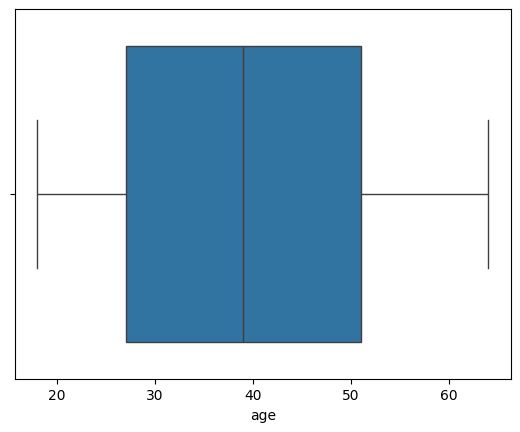

In [ ]:
sns.boxplot(df['age'],orient='h')
plt.show()

In [ ]:
import numpy as np

# Calculate IQR and bounds
q1 = np.quantile(df['age'], 0.25)
q3 = np.quantile(df['age'], 0.75)
IQR = q3 - q1
min_bound = q1 - 1.5 * IQR
max_bound = q3 + 1.5 * IQR

# Reset index
df.reset_index(drop=True, inplace=True)

# Cap outliers
for i in range(len(df)):
    if df.loc[i, 'age'] > max_bound:
        df.loc[i, 'age'] = max_bound
    elif df.loc[i, 'age'] < min_bound:
        df.loc[i, 'age'] = min_bound


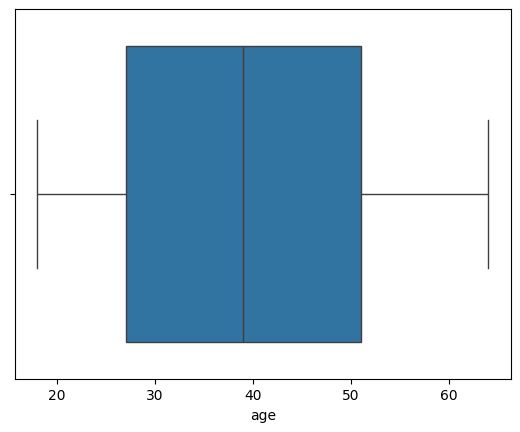

In [ ]:
sns.boxplot(df['age'],orient='h')
plt.show()

In [ ]:
q1 = np.quantile(df['age'],0.25)
q3 = np.quantile(df['age'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True, inplace=True)
for i in range(len(df)):
    if df.loc[i, 'age'] > max_bound:
        df.loc[i, 'age'] = max_bound

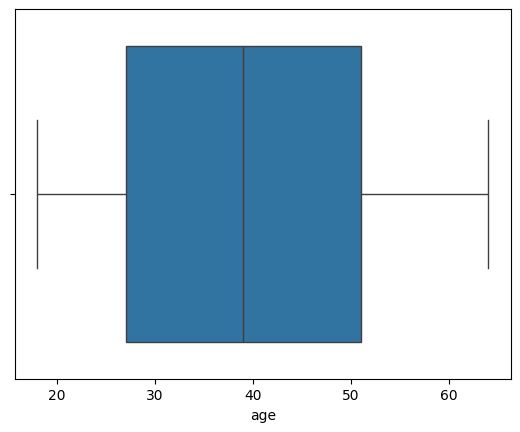

In [ ]:
sns.boxplot(df['age'],orient='h')
plt.show()

In [ ]:
q1 = np.quantile(df['bmi'],0.25)
q3 = np.quantile(df['bmi'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True, inplace=True)
for i in range(len(df)):
    if df.loc[i, 'bmi'] > max_bound:
        df.loc[i, 'bmi'] = max_bound

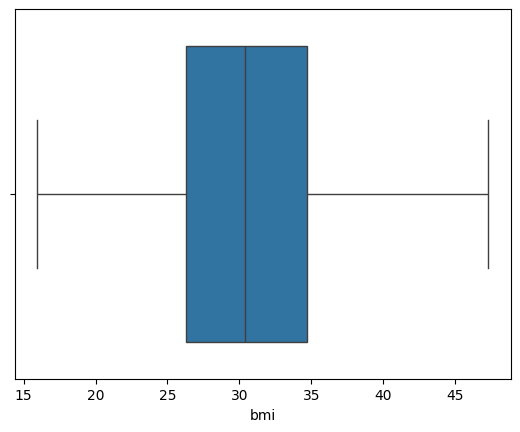

In [ ]:
sns.boxplot(df['bmi'],orient='h')
plt.show()

# checking for corelation

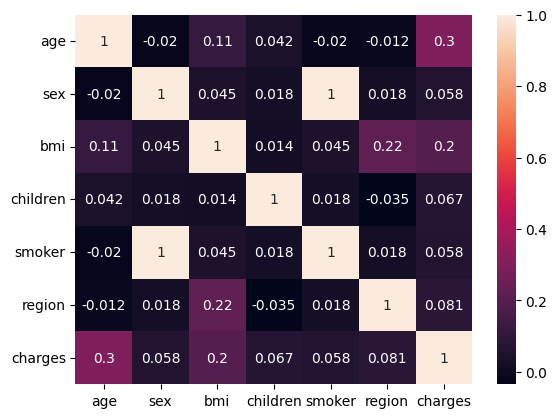

In [ ]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [ ]:
#picking coloumns from highest corelation
df_new = df[['age','bmi','charges']]

# Data scaling

In [ ]:
age_std = StandardScaler()
df_new['age'] = age_std.fit_transform(df_new[['age']])

In [ ]:
bmi_std = StandardScaler()
df_new['bmi'] = bmi_std.fit_transform(df_new[['bmi']])

# model building


In [ ]:
df_new

,age,bmi,charges
0,-1.440418,-0.454032,16884.92400
1,-1.511647,0.515033,1725.55230
2,-0.799350,0.387915,4449.46200
3,-0.443201,-1.311662,21984.47061
4,-0.514431,-0.292246,3866.85520
...,...,...,...
1332,0.767704,0.052787,10600.54830
1333,-1.511647,0.209621,2205.98080
1334,-1.511647,1.023503,1629.83350
1335,-1.297958,-0.800716,2007.94500


# knn

In [ ]:
x=df_new.drop('charges',axis=1)
y=df_new['charges']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train

,age,bmi
1113,-1.155499,-1.013679
967,-1.297958,-0.809796
598,0.910164,1.134937
170,1.693691,1.786208
275,0.554015,-0.668646
...,...,...
1095,0.838934,0.711487
1130,-0.870580,2.517546
1294,-1.369188,-1.428049
860,-0.087053,-0.437523


In [ ]:
y_train

,charges
1113,2396.09590
967,3279.86855
598,33471.97189
170,13405.39030
275,9715.84100
...,...
1095,44641.19740
1130,3693.42800
1294,1964.78000
860,7151.09200


In [ ]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsRegressor()

In [ ]:
knn.score(x_train,y_train)

0.30004262968596396

In [ ]:
knn.score(x_test,y_test)

-0.04695726355232188

In [ ]:
y_pred=knn.predict(x_test)
y_pred

array([11972.08006 ,  4218.64903 , 12860.755194, 17263.9113  ,
       32569.27492 , 13166.395002, 16053.5936  ,  6621.373588,
       23011.283354, 12647.80806 , 13481.10228 , 13704.476942,
       11939.94357 , 22687.912798, 19447.80481 , 12235.63468 ,
       11018.67918 , 12405.26697 ,  5438.14101 , 10064.96035 ,
       11018.67918 , 11927.71984 , 24850.44407 ,  9498.0231  ,
        4995.37107 ,  8395.39877 , 11630.290178, 24666.085672,
       15340.66236 , 25392.158998,  4704.26072 , 16881.8206  ,
        1830.06713 , 13211.82324 , 10060.42838 , 16489.39977 ,
        7995.60758 ,  9181.52841 , 10722.24664 , 15293.556074,
        9816.64787 , 11860.42278 , 10665.422738, 16700.21117 ,
       10150.0266  ,  3962.63363 ,  1995.09004 , 21663.894144,
        3962.63363 ,  6978.62356 ,  3469.76913 , 17988.231168,
        8798.08414 , 10987.77286 , 16160.709914, 31650.085238,
       18049.305498,  7172.397488,  4995.37107 , 16489.65054 ,
       24337.07579 , 11673.70488 , 17364.179406,  4742.

In [ ]:
result=pd.DataFrame({'actual':y_test,'predicted':y_pred})
result

,actual,predicted
899,8688.85885,11972.080060
1063,5708.86700,4218.649030
1255,11436.73815,12860.755194
298,38746.35510,17263.911300
237,4463.20510,32569.274920
...,...,...
534,13831.11520,14403.007890
542,13887.20400,28055.778140
759,3925.75820,2646.736610
1283,47403.88000,29984.488796


In [ ]:
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)


In [ ]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MSE: 192384745.96961462
R² Score: -0.04695726355232188


In [ ]:
#cross validation
x, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

kn = KNeighborsRegressor()

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

scores = cross_val_score(kn, x, y, cv=5, scoring=mse_scorer)

print("MSE scores:", -scores)
print("Average MSE:", -scores.mean())

MSE scores: [198.91240142  91.85005123 145.71724656  90.25401635  58.22050778]
Average MSE: 116.99084466614633


# linear regression

In [ ]:
x=df_new.drop('charges',axis=1)
y=df_new['charges']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(x, y)

LinearRegression()

In [ ]:
print("Intercept:", model.intercept_)
print("Slope(s):", model.coef_)

Intercept: 13279.121486655948
Slope(s): [3383.81721647 2030.84208546]


In [ ]:
y_pred_lin = model.predict(x_test)

In [ ]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lin})
print(results)

           Actual     Predicted
899    8688.85885  12908.384452
1063   5708.86700   9122.114538
1255  11436.73815  18040.593962
298   38746.35510  12551.167917
237    4463.20510  13892.235736
...           ...           ...
534   13831.11520  22546.881648
542   13887.20400  20904.437353
759    3925.75820  10445.612827
1283  47403.88000  20422.380506
1284   8534.67180  13031.484459

[268 rows x 2 columns]


In [ ]:
r2 = r2_score(y_test, y_pred_lin)
mse = mean_squared_error(y_test, y_pred_lin)

print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: 0.15125695256641025
Mean Squared Error: 155961681.77864456


In [ ]:
#cross validation


x, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Create model
ln = LinearRegression()

# Define scoring metric (negative MSE because sklearn maximizes scores)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Perform 5-fold cross-validation
scores = cross_val_score(ln, x, y, cv=5, scoring=mse_scorer)

# Since scores are negative (because lower MSE is better), convert them back
print("MSE scores:", -scores)
print("Average MSE:", -scores.mean())

MSE scores: [102.30862437  85.00727953 116.42227151  58.35468545  44.46093271]
Average MSE: 81.31075871367227


# decision tree

In [ ]:
dec = DecisionTreeRegressor(random_state = 0)

In [ ]:
dec.fit(x_train, y_train)

DecisionTreeRegressor(random_state=0)

In [ ]:
dec.score(x_train,y_train)

0.9682510975225602

In [ ]:
dec.score(x_test,y_test)

-0.6079832696088088

In [ ]:
y_pred_dec = dec.predict(x_test)

In [ ]:
rmse = float(format(np.sqrt(mean_squared_error(y_test, y_pred_dec)), '.3f'))
print("\nRMSE: ", rmse)


RMSE:  17189.435


In [ ]:
r2 = r2_score(y_test, y_pred_dec)
mse = mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: -0.6079832696088088
Mean Squared Error: 192384745.96961462


In [ ]:
#cross validation
x, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

dr = DecisionTreeRegressor()

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

scores = cross_val_score(dr, x, y, cv=5, scoring=mse_scorer)

print("MSE scores:", -scores)
print("Average MSE:", -scores.mean())

MSE scores: [237.23534125 186.80158009 175.94965389 147.87792206 122.33047626]
Average MSE: 174.0389947088268


# random forest

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf.predict(x_test)

In [ ]:
rmse = float(format(np.sqrt(mean_squared_error(y_test, y_pred_rf)), '.3f'))
print("\nRMSE: ", rmse)


RMSE:  14049.737


In [ ]:
r2 = r2_score(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: -0.07422365349797189
Mean Squared Error: 197395110.46663707


In [ ]:
#cross validation
x, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

rr = RandomForestRegressor()

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

scores = cross_val_score(rr, x, y, cv=5, scoring=mse_scorer)

print("MSE scores:", -scores)
print("Average MSE:", -scores.mean())

MSE scores: [201.96673805 135.68711306 161.74743898 100.43510568  76.02905482]
Average MSE: 135.17309011834487


#adaboost

In [ ]:
ab=AdaBoostRegressor(n_estimators=100, random_state=42)
ab.fit(x_train, y_train)

AdaBoostRegressor(n_estimators=100, random_state=42)

In [ ]:
y_pred_ab = ab.predict(x_test)

In [ ]:
rmse = float(format(np.sqrt(mean_squared_error(y_test, y_pred_ab)), '.3f'))
print("\nRMSE: ", rmse)


RMSE:  12921.548


In [ ]:
r2 = r2_score(y_test, y_pred_ab)
mse = mean_squared_error(y_test, y_pred_ab)
print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: 0.0913692317566519
Mean Squared Error: 166966413.639038


In [ ]:
#cross validation
x, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

ar = AdaBoostRegressor()

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

scores = cross_val_score(ar, x, y, cv=5, scoring=mse_scorer)

print("MSE scores:", -scores)
print("Average MSE:", -scores.mean())

MSE scores: [216.89844993  96.18197101 138.95419709  95.94238101  70.92957452]
Average MSE: 123.78131471361534


# support vector regression

In [ ]:
sv = SVR()
sv.fit(x_train, y_train)

SVR()

In [ ]:
y_pred_sv = sv.predict(x_test)

In [ ]:
rmse = float(format(np.sqrt(mean_squared_error(y_test, y_pred_sv)), '.3f'))
print("\nRMSE: ", rmse)


RMSE:  14430.577


In [ ]:
r2 = r2_score(y_test, y_pred_sv)
mse = mean_squared_error(y_test, y_pred_sv)
print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: -0.13324989369820517
Mean Squared Error: 208241540.04097646


In [ ]:
#cross validation
x, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

sn = SVR()

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

scores = cross_val_score(sn, x, y, cv=5, scoring=mse_scorer)

print("MSE scores:", -scores)
print("Average MSE:", -scores.mean())

MSE scores: [1368.49373618  619.84648623  811.48273147 1439.66643655  958.42492552]
Average MSE: 1039.5828631911638


#model comparison graph

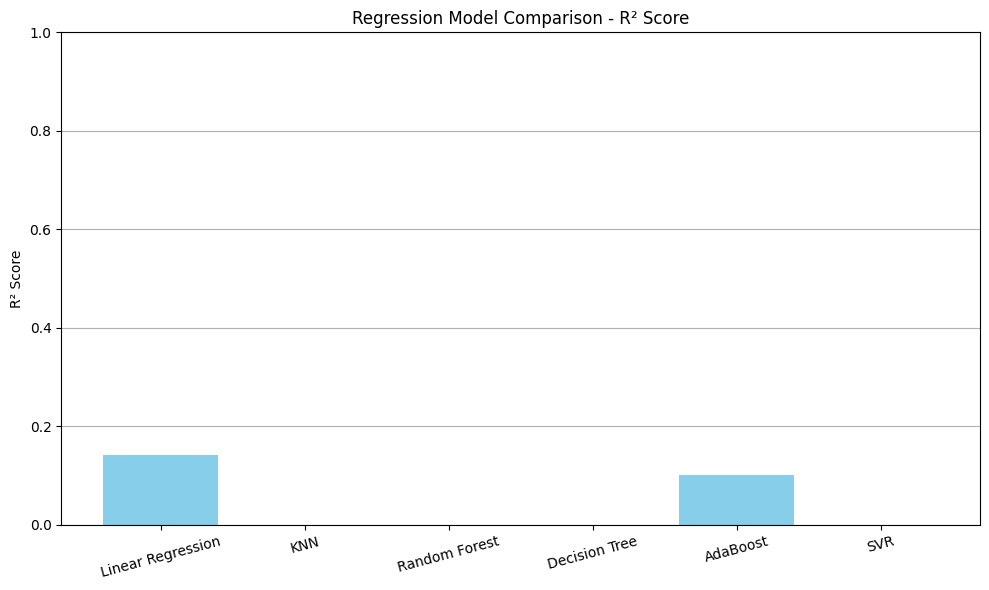

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "SVR": SVR()
}

# Train and evaluate models
r2_scores = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    r2_scores[name] = r2_score(y_test, y_pred)

# Plotting R2 Score comparison
plt.figure(figsize=(10, 6))
plt.bar(r2_scores.keys(), r2_scores.values(), color='skyblue')
plt.title('Regression Model Comparison - R² Score')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#model comparison graph cross validation

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

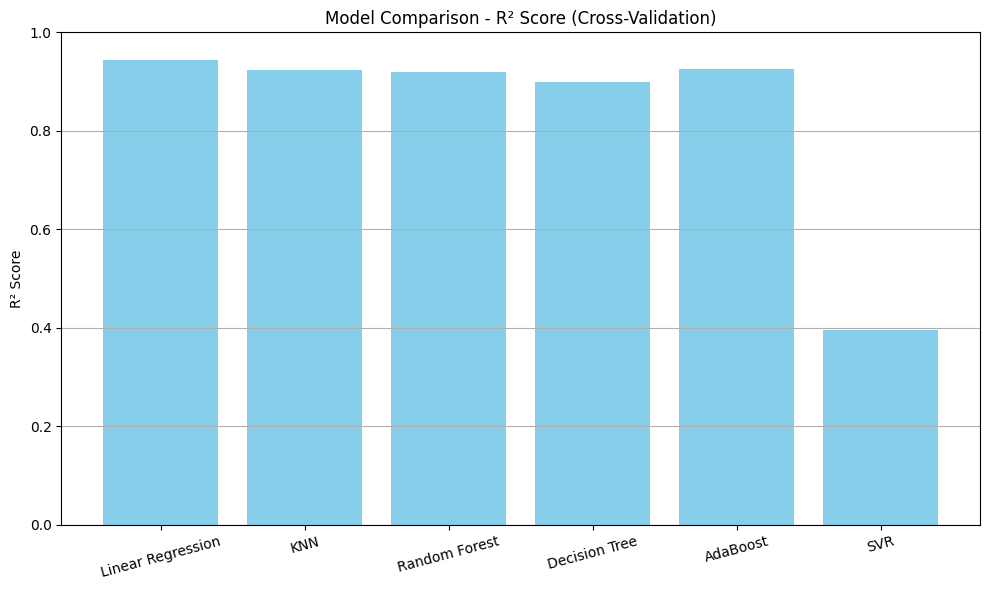

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "SVR": SVR()
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = {}

for name, model in models.items():
    r2 = cross_val_score(model, x, y, cv=cv, scoring='r2')
    scores[name] = np.mean(r2)
    plt.figure(figsize=(10, 6))
plt.bar(scores.keys(), scores.values(), color='skyblue')
plt.title('Model Comparison - R² Score (Cross-Validation)')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()